In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import torch

import sys
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution
from tqdm import tqdm

sys.path.append("../../")
from utils.plotting import make_corner
from utils.mahaTools import mahalanobis_dist
from utils.ANALYSISutils import median_score

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [6]:
n100 = ["Nref20000_Nbkg4000_Nsig100_8t_alt.npy","Nref20000_Nbkg4000_Nsig100_8t_null.npy"]
n160 = ["Nref20000_Nbkg4000_Nsig160_8t_alt.npy","Nref20000_Nbkg4000_Nsig160_8t_null.npy"]
n200 = ["Nref20000_Nbkg4000_Nsig200_8t_alt.npy","Nref20000_Nbkg4000_Nsig200_8t_null.npy"]
n20 = ["Nref20000_Nbkg4000_Nsig20_8t_alt.npy","Nref20000_Nbkg4000_Nsig20_8t_null.npy"]
n400 = ["Nref20000_Nbkg4000_Nsig400_8t_alt.npy","Nref20000_Nbkg4000_Nsig400_8t_null.npy"]
n40 = ["Nref20000_Nbkg4000_Nsig40_8t_alt.npy","Nref20000_Nbkg4000_Nsig40_8t_null.npy"]

bkg_tot = 4000
files = {
    100/bkg_tot:n100,
    160/bkg_tot:n160,
    200/bkg_tot:n200,
    20/bkg_tot:n20,
    #400/bkg_tot:n400,
    40/bkg_tot:n40
}
sig_fracs = sorted(list(files.keys()))

In [7]:
base = "Mahalanobis_gwak_fixed/"
zscores = []
for sf in sig_fracs:
    null = np.load(base+files[sf][1])
    alt = np.load(base+files[sf][0])
    t_empirical = np.sum(1.*(null>np.mean(alt)))*1./null.shape[0]
    if t_empirical==0:
        t_empirical = 1./null.shape[0]
    z = norm.ppf(1-t_empirical)
    zscores.append(z)

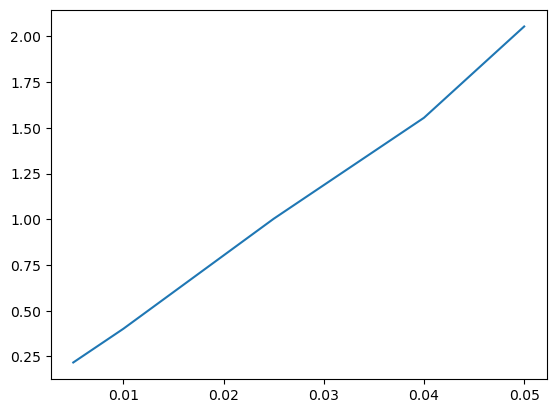

In [8]:
plt.plot(sig_fracs,zscores)

In [9]:
np.savez("gwak_maha_empiricalZscore.npz",zscores=zscores,fracs=sig_fracs)

# compute myself

100%|██████████| 500/500 [00:07<00:00, 66.66it/s]


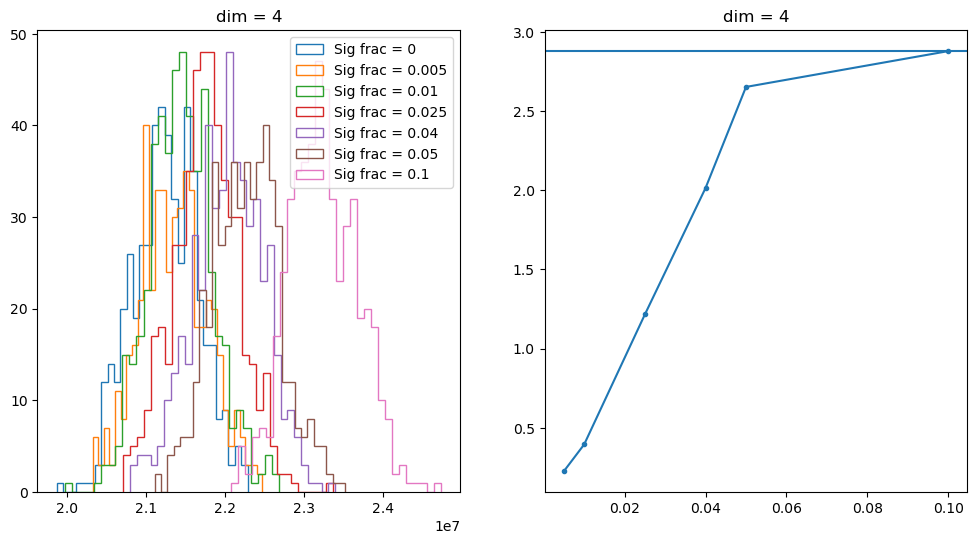

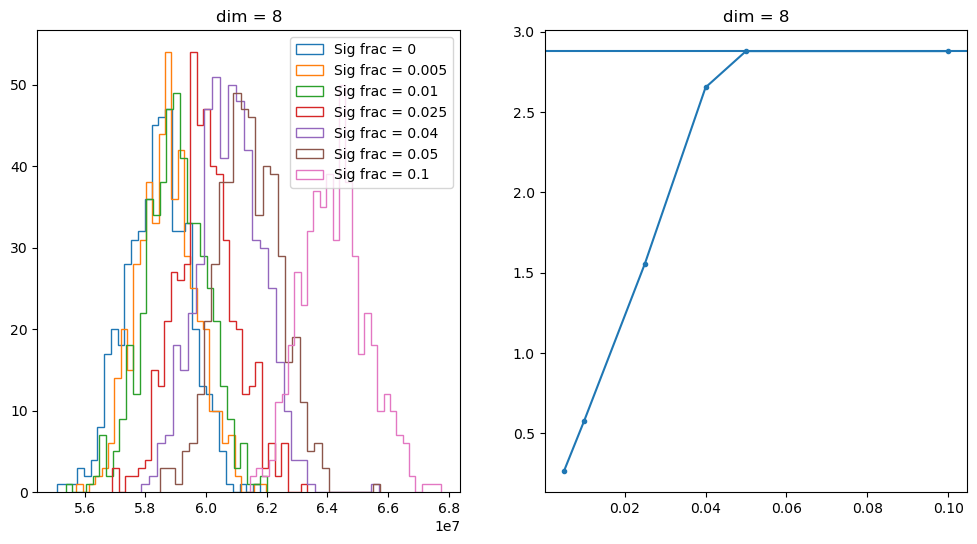

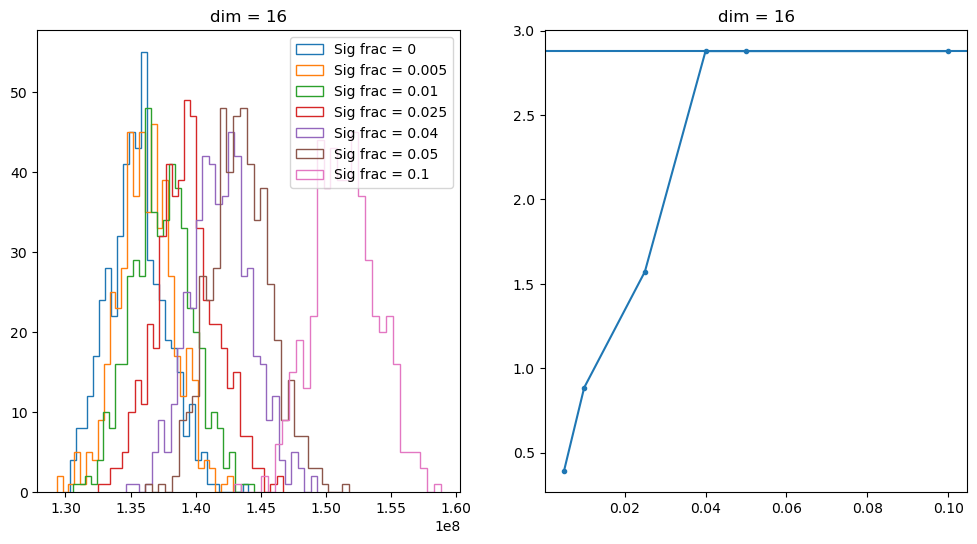

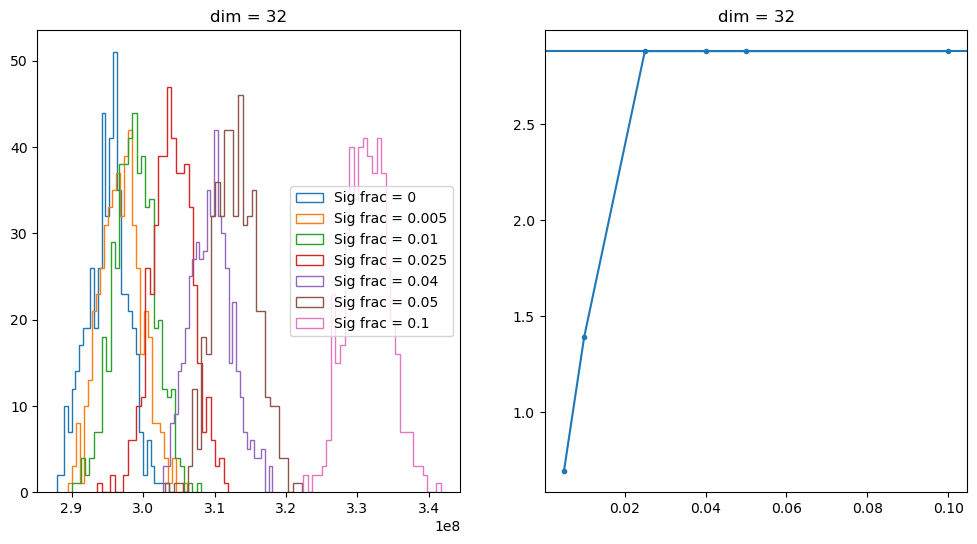

In [2]:
for dim in [4,8,16,32]:
    dim_label = f"_dim{dim}" if dim != 4 else ""

    base = f"/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/GWAK/results/"
    if dim != 4:
        base += f"dim{dim}/"
    f_ref = f"{base}/test.npz"
    f_anom = f"{base}/anomaly.npz"

    ref_data_npz = np.load(f_ref)
    anom_data_npz = np.load(f_anom)
    ref_data = ref_data_npz['data']
    ref_labels = ref_data_npz['label']
    anom_data = anom_data_npz['data']
    anom_labels = anom_data_npz['label']

    nref = 20000
    nbkg = 4000
    sig_fracs = [0, 0.005, 0.01, 0.025, 0.04, 0.05, 0.1]
    Ntoys = 500

    all_ts = []
    for fsig in sig_fracs:
        nsig = int(fsig * nbkg)
        ts = []
        for i in tqdm(range(Ntoys)):
            ref_perm = np.random.permutation(len(ref_data))
            anom_perm = np.random.permutation(len(anom_data))
            ref = ref_data[ref_perm[:nref]]
            ref_lab = ref_labels[ref_perm[:nref]]
            data = np.concatenate([ref_data[ref_perm[nref:nref+nbkg]],anom_data[anom_perm[:nsig]]])
            t,M = mahalanobis_dist(torch.tensor(data),torch.tensor(ref),torch.tensor(ref_lab),plot=False)
            ts.append(t.item())
        all_ts.append(ts)
    all_ts = [np.array(a) for a in all_ts]

    fig,axes = plt.subplots(1,2,figsize=(12,6))
    plt.sca(axes[0])
    for i,ts in enumerate(all_ts):
        plt.hist(ts,bins=30,histtype='step',label=f"Sig frac = {sig_fracs[i]}")
    plt.legend()
    plt.title(f"dim = {dim}")

    from scipy.stats import norm
    zscores = []
    tref = all_ts[0]
    for tobs in all_ts[1:]:
        t_empirical = np.sum(1.*(tref>np.mean(tobs)))*1./tref.shape[0]
        if t_empirical==0:
            empirical_lim='>'
            t_empirical = 1./tref.shape[0]
        z = norm.ppf(1-t_empirical)
        zscores.append(z)
    plt.sca(axes[1])
    plt.plot(sig_fracs[1:],zscores,marker='.')
    plt.axhline(norm.ppf(1-1/len(tref)))
    plt.title(f"dim = {dim}")

    np.savez(f"gwak_maha_empiricalZscore{dim_label}.npz",zscores=zscores,fracs=sig_fracs[1:])